In [6]:
from typing import Annotated,Sequence,TypedDict
from langchain_core.messages import BaseMessage,SystemMessage,AIMessage,HumanMessage,ToolMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from langchain_core.tools import tool

load_dotenv()
document_content=""

In [7]:
class AgentClass(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

def update(content:str)->str:
    """This function is used to update the file with content"""
    global document_content
    document_content=content
    return(f"The document has been updated sucessfully the current content is :{document_content}")

def save(file_name:str):
    """This function provides files name to save the document
      Args:
      file_name:Name of the text file
    """
    global document_content

    if not file_name.endswith("txt"):
        file_name=f"{file_name}.txt"
    
    try:
        with open(file_name,"w") as file:
            file.write(document_content)
        return f"Document had been sucessfully saved to {file_name}"
    except Exception as e:
        print(f"Error Saving Document: {str(e)}")

tools=[update,save]

model=ChatOpenAI(model="gpt-4o").bind_tools(tools=tools)

def our_agent(state:AgentClass)->AgentClass:
    system_message=SystemMessage(content=f"""
    Your are a Drafter, a helpful writing Assistant. Your going to help the user update and modify the document.
    -If the user wants to update or modify content use 'Update' tools and complete update content.
    -If the user wants to save and finish you need to use 'save' tool
    -Make sure you show the current Document state after modification.
    The Current docuemnt content:f{document_content}
    """
    )
    
    if not state["messages"]:
        user_input="I'm Ready to help you update document. What would you like to create?"
        user_message=HumanMessage(content=user_input)

    else:
        user_input=input("\nwhat would you like to do with these document?")
        print(f"USER:{user_input}")
        user_message=HumanMessage(content=user_input)
    
    all_messages=[system_message]+list(state["messages"])+[user_message]
    response=model.invoke(all_messages)

    print(f"\nAI:{response.content}")
    if hasattr(response,"tool_calls") and response.tool_calls:
        print(f"USING TOOLS:{[tc['name'] for tc in response.tool_calls]}")

    return {"messages":list(state["messages"])+[user_message,response]}

    
def should_continue(state:AgentClass):
    """Determines does the conversation continue or ends"""
    messages=state["messages"]
    if not messages:
        return "continue"
    for message in messages:
        if (isinstance(messages,ToolMessage) and "saved" in messages.content.lower() and "document" in messages.content.lower()):
            return "end"
    
    return "continue"

def print_messages(messages):
    """Used to print the output in more readble format"""
    if not messages:
        return
    for message in messages[-3:]:
        if isinstance(message,ToolMessage):
            print(f"\nTool Results:{message.content}")
    


graph=StateGraph(AgentClass)
graph.add_node("Agent",our_agent)
graph.add_node("Tools",ToolNode(tools))
graph.set_entry_point("Agent")

graph.add_edge("Agent","Tools")
graph.add_conditional_edges(
    "Tools",
    should_continue,
    {
        "continue":"Agent",
        "end":END,
    },

)
Agent=graph.compile()


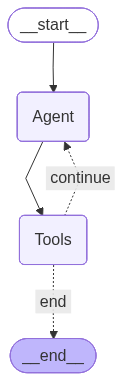

In [8]:
from IPython.display import Image,display
display(Image(Agent.get_graph().draw_mermaid_png()))

In [ ]:
def run_document_agent():
    print("\n ====DRAFTER=====")
    state={"messages":[]}

    for step in Agent.stream(state,stream_mode="values"):
        if "messages" in step:
            print_messages(step["messages"])
            
    print("====DRAFTER-FINISED====")

run_document_agent()     


 ====DRAFTER=====

AI:The document content is currently empty. Please specify the content you would like to add or update in the document.
USER:i would like to wrote an essay on the "Ai imapct in 2026"

AI:
USING TOOLS:['update']

Tool Results:The document has been updated sucessfully the current content is :Title: The Impact of AI in 2026

Introduction
The advent of artificial intelligence (AI) has transformed industries and aspects of daily life over the past few decades. As we approach 2026, AI's impact is poised to become even more significant. This essay explores the expected advancements in AI and their implications across various sectors.

Advancements in AI Technology
By 2026, AI technology is expected to have made substantial progress. Machine learning algorithms will become even more sophisticated, enabling AI systems to understand and process data with unprecedented accuracy. Innovations in natural language processing will further enhance AI's ability to interact with human

KeyboardInterrupt: Interrupted by user